In [2]:
"""
Data Analysis Script
# - Price distribution analysis across categories
# - Rating patterns and statistical summaries
# - Correlation analysis between price, rating, and availability
# - Category popularity (frequency distributions) - Comparative analysis between data sources
# - Descriptive statistics, outliers, hypothesis testing
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import plotly.express as px
from datetime import datetime

# File path
CLEANED_CSV = '../data_processing/cleaned_book_data.csv'

# Load data
df = pd.read_csv(CLEANED_CSV)

print("Loaded dataset shape:", df.shape)
print(df.dtypes)

Loaded dataset shape: (1049, 6)
source           object
title            object
price           float64
rating          float64
category         object
availability     object
dtype: object


In [3]:
print(df.head())

           source                                 title  price  rating  \
0  books.toscrape                  a light in the attic  51.77     3.0   
1  books.toscrape                    tipping the velvet  53.74     1.0   
2  books.toscrape                            soumission  50.10     1.0   
3  books.toscrape                         sharp objects  47.82     4.0   
4  books.toscrape  sapiens a brief history of humankind  54.23     5.0   

             category availability  
0              poetry     in stock  
1  historical fiction     in stock  
2             fiction     in stock  
3             mystery     in stock  
4             history     in stock  


In [4]:
# Missing values
print('\nMissing values per column:')
print(df.isna().sum())


Missing values per column:
source           0
title            0
price            0
rating           0
category         0
availability    30
dtype: int64


In [5]:
# Basic numeric summary
print('\nDescriptive statistics for numeric columns:')
print(df[['price', 'rating']].describe())


Descriptive statistics for numeric columns:
             price       rating
count  1049.000000  1049.000000
mean     36.490915     2.849571
std      43.397067     1.490780
min       0.000000     0.000000
25%      21.150000     2.000000
50%      35.280000     3.000000
75%      47.310000     4.000000
max     999.990000     5.000000


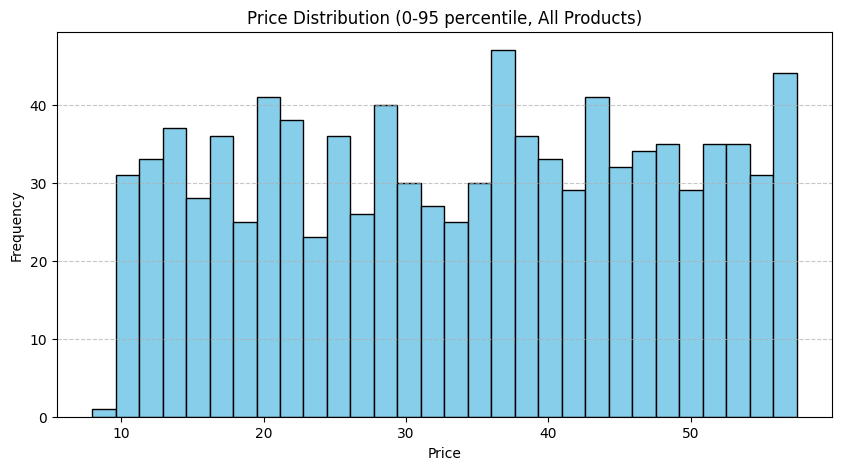

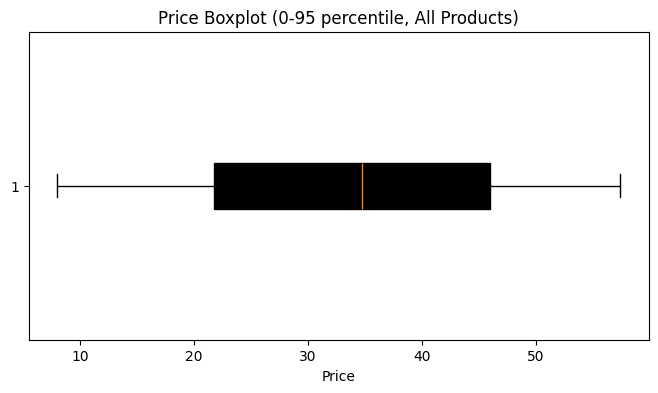

In [6]:
# Price distribution analysis
# - Histogram and boxplot for overall price distribution
# - Boxplots by top categories

# Prepare price series
price_series = df['price'].dropna()
price_series = price_series[price_series > 0]

# Histogram: cap at 95th percentile to avoid extreme outliers
upper_limit = price_series.quantile(0.95)
capped_prices = price_series[price_series <= upper_limit]

plt.figure(figsize=(10,5))
plt.hist(capped_prices, bins=30, color='skyblue', edgecolor='black')
plt.title('Price Distribution (0-95 percentile, All Products)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#  Boxplot overall (capped at 95th percentile)
plt.figure(figsize=(8,4))
plt.boxplot(capped_prices, vert=False, patch_artist=True, boxprops=dict(facecolor='black'))
plt.title('Price Boxplot (0-95 percentile, All Products)')
plt.xlabel('Price')
plt.show()


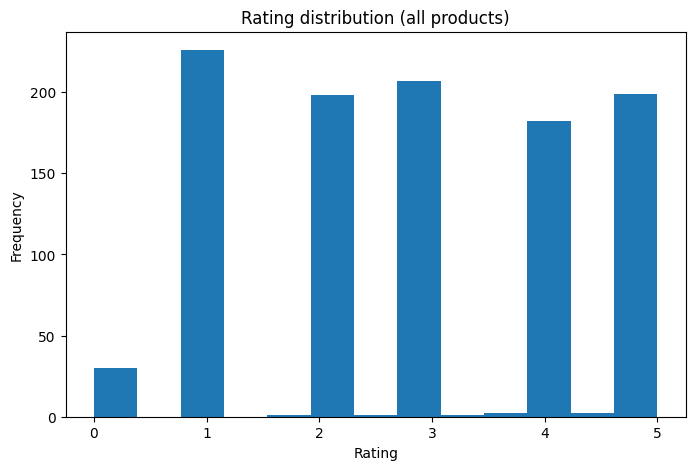

                count      mean  median       std
category                                         
default           152  2.835526     3.0  1.425613
nonfiction        110  2.881818     3.0  1.405963
sequential art     75  2.973333     3.0  1.345396
add a comment      67  2.761194     3.0  1.338130
fiction            65  3.184615     3.0  1.445816
young adult        54  3.296296     4.0  1.512584
fantasy            47  3.042553     3.0  1.413559
romance            35  2.628571     3.0  1.373825
mystery            32  2.937500     3.0  1.389767
food and drink     30  2.900000     3.0  1.493665


In [7]:
# Rating patterns and statistical summaries
# Rating histogram
rating_series = df['rating'].dropna()
plt.figure(figsize=(8,5))
plt.hist(rating_series, bins='auto')
plt.title('Rating distribution (all products)')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Rating summary by category (top 10)
rating_by_cat = df.groupby('category')['rating'].agg(['count','mean','median','std']).sort_values('count', ascending=False).head(10)
print(rating_by_cat)
rating_by_cat.to_csv('top10_rating_by_category.csv')


Pairwise Pearson correlation (Books to Scrape):
           price    rating
price   1.000000  0.028475
rating  0.028475  1.000000

Pairwise Spearman correlation (Books to Scrape):
           price    rating
price   1.000000  0.029572
rating  0.029572  1.000000


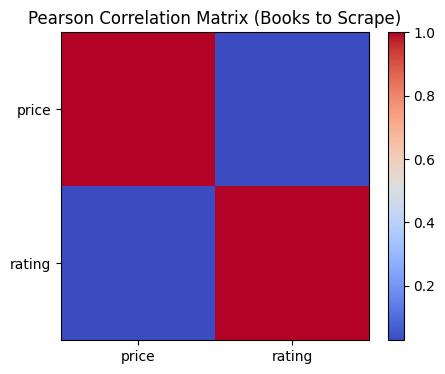

In [8]:
# Correlation analysis between price and rating
# Filter only Books to Scrape
books_df = df[df['source'] == 'books.toscrape'].copy()

# Prepare correlation DataFrame
corr_df = books_df[['price', 'rating']].dropna()

# Pairwise correlations
print('\nPairwise Pearson correlation (Books to Scrape):')
print(corr_df.corr(method='pearson'))

print('\nPairwise Spearman correlation (Books to Scrape):')
print(corr_df.corr(method='spearman'))

# Heatmap using matplotlib
corr = corr_df.corr(method='pearson')
plt.figure(figsize=(5,4))
plt.imshow(corr, interpolation='nearest', cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Pearson Correlation Matrix (Books to Scrape)')
plt.show()


category
default                 152
nonfiction              110
sequential art           75
add a comment            67
fiction                  65
young adult              54
fantasy                  47
romance                  35
mystery                  32
food and drink           30
childrens                29
historical fiction       26
books and literature     21
poetry                   19
classics                 19
history                  18
horror                   17
womens fiction           17
science fiction          16
science                  14
Name: count, dtype: int64


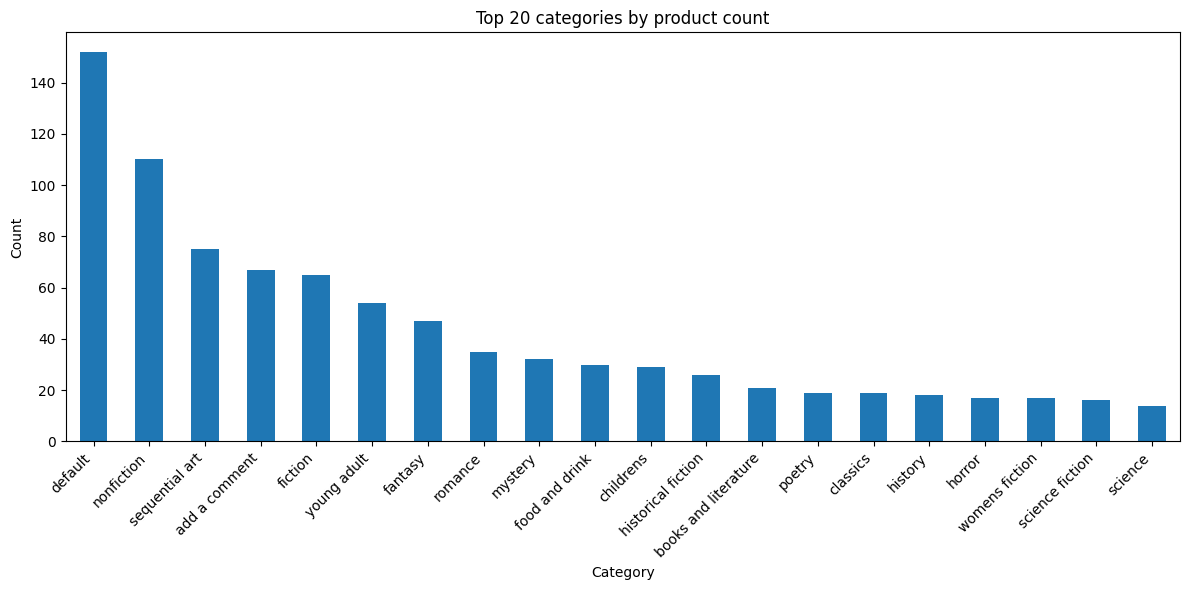

In [9]:
# Category popularity analysis (frequency distributions)
cat_counts = df['category'].value_counts()
print(cat_counts.head(20))
cat_counts.head(20).to_csv('top20_category_counts.csv')

# Bar chart top 20
plt.figure(figsize=(12,6))
cat_counts.head(20).plot(kind='bar')
plt.title('Top 20 categories by product count')
plt.ylabel('Count')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

           source  count  mean_price  median_price  mean_rating
0  books.toscrape    999   35.073123         36.00     2.920921
1    fakestoreapi     20  162.046000         56.49     3.560000
2   nyt_books_rss     30    0.000000          0.00     0.000000


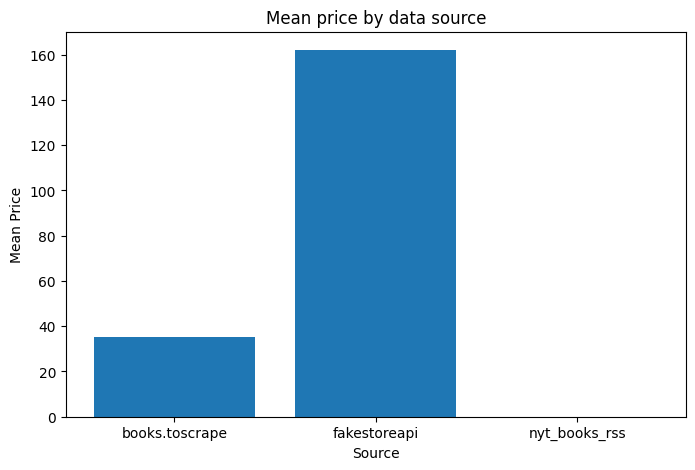

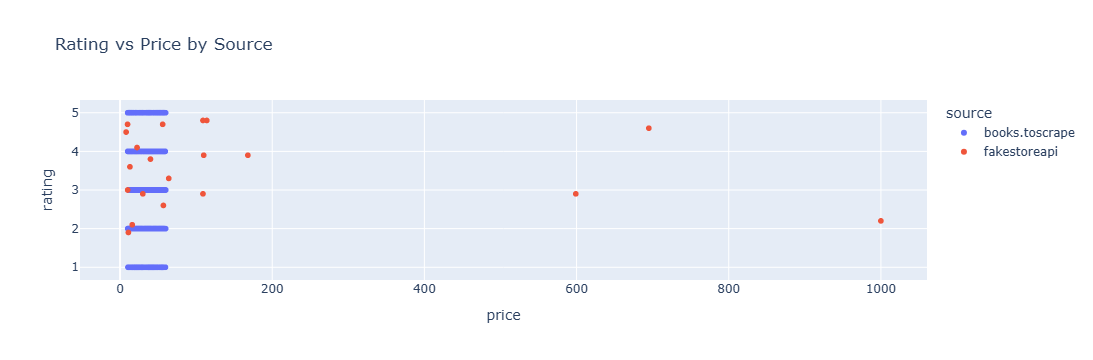

In [10]:
# Comparative analysis between data sources

# Mean price, mean rating, counts by source
source_summary = df.groupby('source').agg(
    count=('title','count'),
    mean_price=('price','mean'),
    median_price=('price','median'),
    mean_rating=('rating','mean')
).reset_index()

print(source_summary)
source_summary.to_csv('data_source_summary.csv', index=False)

# Bar chart: compare mean price by source
plt.figure(figsize=(8,5))
plt.bar(source_summary['source'], source_summary['mean_price'])
plt.title('Mean price by data source')
plt.xlabel('Source')
plt.ylabel('Mean Price')
plt.show()

# Scatter plot: rating vs price colored by source (interactive)
if 'source' in df.columns:
    fig = px.scatter(
        df[df['price'] > 0],
        x='price',
        y='rating',
        color='source',
        hover_data=['title'],
        title='Rating vs Price by Source'
    )
    fig.show()

In [11]:
# Descriptive statistics (mean, median, mode, std)
def descriptive_stats(series):
    series_nonnull = series.dropna()
    return {
    'count': series_nonnull.count(),
    'mean': series_nonnull.mean(),
    'median': series_nonnull.median(),
    'mode': series_nonnull.mode().iat[0] if not series_nonnull.mode().empty else np.nan,
    'std': series_nonnull.std(),
    'min': series_nonnull.min(),
    'max': series_nonnull.max()
    }

price_stats = descriptive_stats(df['price'])
rating_stats = descriptive_stats(df['rating'])

print('Price stats:', price_stats)
print('Rating stats:', rating_stats)

# Save stats to dataframe for reporting
stats_df = pd.DataFrame([price_stats, rating_stats], index=['price', 'rating'])
stats_df.to_csv('descriptive_statistics.csv')

Price stats: {'count': np.int64(1049), 'mean': np.float64(36.49091515729266), 'median': np.float64(35.28), 'mode': np.float64(0.0), 'std': np.float64(43.397067267778944), 'min': np.float64(0.0), 'max': np.float64(999.99)}
Rating stats: {'count': np.int64(1049), 'mean': np.float64(2.8495710200190656), 'median': np.float64(3.0), 'mode': np.float64(1.0), 'std': np.float64(1.4907802874397358), 'min': np.float64(0.0), 'max': np.float64(5.0)}


In [12]:
# Outlier detection (IQR & Z-score)
# IQR method for price
Q1 = price_series.quantile(0.25)
Q3 = price_series.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(df['price'] < lower) | (df['price'] > upper)][['title','price','category','source']]
print('IQR outliers (price):', outliers_iqr.shape[0])
outliers_iqr.to_csv('price_outliers_iqr.csv', index=False)

# Z-score method for price
z_scores = np.abs(stats.zscore(price_series))
# Map z_scores back to original df indices
price_idx = price_series.index
z_outliers_idx = price_idx[z_scores > 3]
z_outliers = df.loc[z_outliers_idx, ['title','price','category','source']]
print('Z-score outliers (price):', z_outliers.shape[0])
z_outliers.to_csv('price_outliers_zscore.csv', index=False)

IQR outliers (price): 8
Z-score outliers (price): 3


In [13]:
# Hypothesis testing: compare prices between two categories

# Automatic selection of top two categories with enough observations
min_samples = 5
top_cats = df['category'].value_counts()
candidates = top_cats[top_cats >= min_samples].index.tolist()

if len(candidates) >= 2:
    cat_a, cat_b = candidates[0], candidates[1]
    print('Comparing categories:', cat_a, 'vs', cat_b)
    prices_a = df.loc[(df['category']==cat_a) & (df['price']>0), 'price'].dropna()
    prices_b = df.loc[(df['category']==cat_b) & (df['price']>0), 'price'].dropna()

    # Normality tests
    print('\nShapiro test p-values (normality):')
    p_a = stats.shapiro(prices_a.sample(min(500,len(prices_a))))[1] if len(prices_a) >= 3 else np.nan
    p_b = stats.shapiro(prices_b.sample(min(500,len(prices_b))))[1] if len(prices_b) >= 3 else np.nan
    print(cat_a, p_a)
    print(cat_b, p_b)

    # Variance equality
    levene_p = stats.levene(prices_a, prices_b)[1] if len(prices_a) >= 2 and len(prices_b) >= 2 else np.nan
    print('Levene p-value (equal variances):', levene_p)
    
    # Choose t-test or Mann-Whitney
    if (not np.isnan(p_a) and p_a > 0.05) and (not np.isnan(p_b) and p_b > 0.05):
        # approximately normal
        t_res = stats.ttest_ind(prices_a, prices_b, equal_var=(levene_p>0.05))
        print('\nT-test result:', t_res)
    else:
        mw_res = stats.mannwhitneyu(prices_a, prices_b, alternative='two-sided')
        print('\nMann-Whitney U result:', mw_res)
    
    # Effect size (Cohen's d)
    def cohens_d(x, y):
        nx, ny = len(x), len(y)
        dof = nx + ny - 2
        pooled_std = np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / dof)
        return (x.mean() - y.mean()) / pooled_std
    
    try:
        d = cohens_d(prices_a, prices_b)
        print('Cohen\'s d:', d)
    except Exception as e:
        print('Could not compute Cohen\'s d:', e)
else:
    print('Not enough categories with minimum samples for hypothesis test.')

Comparing categories: default vs nonfiction

Shapiro test p-values (normality):
default 2.227958027126153e-05
nonfiction 0.0011350287738253184
Levene p-value (equal variances): 0.6147719814457375

Mann-Whitney U result: MannwhitneyuResult(statistic=np.float64(8438.5), pvalue=np.float64(0.897475130922023))
Cohen's d: 0.009345220151233338
